In [1]:
import torch

### set up CUDA as device if available
if torch.cuda.is_available():
    print("GPU is available")
    device = torch.device("cuda")
    cuda_id = torch.cuda.current_device()
    print(f"ID of current CUDA device:{torch.cuda.current_device()}")
    print(f"Name of current CUDA device:{torch.cuda.get_device_name(cuda_id)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("GPU is not available, using CPU")
    device = torch.device("cpu")
print(f"device: {device}")

GPU is available
cuda
CUDA version: 12.4
ID of current CUDA device:0
Name of current CUDA device:NVIDIA H200


In [2]:
import numpy as np
import random
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm, trange
from IPython import display
from sklearn.metrics import average_precision_score
from conf_and_plot import confusion_matrix_plots
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def seed_all(seed):
    if not seed:
        seed = 10

    print("[ Using Seed : ", seed, " ]")

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_all(2025)

[ Using Seed :  2025  ]


In [3]:
scint_thresh = 0.1 # set the phase scintillation threshold

### following variable not being used anywhere
scint_outlier_thresh = 5. # set the value that determines phase scintillation outliers (these data samples will be removed)

processed_data_2015 = pd.read_csv("processed_data_2015.csv")
processed_data_2015 = processed_data_2015.drop(processed_data_2015.columns[0], axis=1)
predicted_label = 'sigmaPhi projected to vertical at prediction time [radians]'
y = processed_data_2015[predicted_label].values
print(y.shape)

X_fSelect = processed_data_2015.drop(predicted_label, axis=1)
X_fSelect = X_fSelect.values
print(X_fSelect.shape)

(4465846,)
(4465846, 15)


In [4]:
### tss model 8-2 plat
params = {'cnn_filters': 48, 
          'fc_size': 2048, 
          'sequence_length': 45, 
          'dropout_p': 0.05, 
          'batch_size': 1024, 
          'lr': 0.01, 
          'optimizer_type': 'sgd', 
          'weight_decay': 0.05, 
          'loss': 'bce', 
          'bce_pos_class_weight': 50, 
          'num_epochs': 150, 
          'scheduler_type': 'plat'}

### parameters
cnn_filters= 48
fc_size= 2048
seq_length = 45
dropout_p= 0.05
batch_size= 1024
learning_rate= 0.01
optimizer_type='sgd'
weight_decay = 0.05
loss = 'bce'
bce_pos_class_weight= 50
sgd_momentum = 0.9

num_epochs = 150
scheduler_type = 'plat'  # None, 'plat', or 'cos'
scheduler_t = 49  # for 'cos'
metric = 'tss' # metric for 'plat' scheduler : 'tss' or 'hss'

### set training/validation/test size parameters
training_data_size = 500000
test_data_size = 3465846
### test_data_size is set such that validation data size = 500000

# final train tss = 0.7293 : final val tss = 0.6181
# final train hss = 0.2060 : final val hss = 0.1183
# test_TSS_2016: 0.6374
# test_HSS_2016: 0.1483
# AUC-ROC: 0.89
# Precision-Recall AUC: 0.23



In [5]:
### hss model 8-12 cos
params = {'cnn_filters': 96, 
          'fc_size': 2048, 
          'sequence_length': 45, 
          'dropout_p': 0.1, 
          'batch_size': 1024, 
          'lr': 0.01, 
          'optimizer_type': 'sgd', 
          'weight_decay': 0.02, 
          'loss': 'bce', 
          'bce_pos_class_weight': 5, 
          'num_epochs': 150, 
          'scheduler_t': 175, 
          'scheduler_type': 'cos'}

### parameters
cnn_filters= 96
fc_size= 2048
seq_length = 45
dropout_p= 0.1
batch_size= 1024
learning_rate= 0.01
optimizer_type='sgd'
weight_decay = 0.02
loss = 'bce'
bce_pos_class_weight= 5
sgd_momentum = 0.9

num_epochs = 150
scheduler_type = 'cos'  # None, 'plat', or 'cos'
scheduler_t = 175  # for 'cos'
metric = 'tss' # metric for 'plat' scheduler : 'tss' or 'hss'

### set training/validation/test size parameters
training_data_size = 500000
test_data_size = 3465846
### test_data_size is set such that validation data size = 500000

# final train tss = 0.5180 : final val tss = 0.3272
# final train hss = 0.4746 : final val hss = 0.2918
# test_TSS_2016: 0.3100
# test_HSS_2016: 0.2910
# AUC-ROC: 0.88
# Precision-Recall AUC: 0.24



In [7]:
### tss+hss model 3-1 plat
params = {'cnn_filters': 512, 
          'fc_size': 1536, 
          'sequence_length': 45, 
          'dropout_p': 0.1, 
          'batch_size': 1024, 
          'lr': 0.005, 
          'optimizer_type': 'sgd', 
          'weight_decay': 0.05, 
          'loss': 'bce', 
          'bce_pos_class_weight': 15, 
          'num_epochs': 100, 
          'scheduler_type': 'plat'}

### parameters
cnn_filters= 512
fc_size= 1536
seq_length = 45
dropout_p= 0.1
batch_size= 1024
learning_rate= 0.005
optimizer_type='sgd'
weight_decay = 0.05
loss = 'bce'
bce_pos_class_weight= 15
sgd_momentum = 0.9

num_epochs = 100
scheduler_type = 'plat'  # None, 'plat', or 'cos'
scheduler_t = 75  # for 'cos'
metric = 'tss' # metric for 'plat' scheduler : 'tss' or 'hss'

### set training/validation/test size parameters
training_data_size = 500000
test_data_size = 3465846
### test_data_size is set such that validation data size = 500000

# model 3-1: train tss = 0.6833 : val tss = 0.5934
# model 3-1: train hss = 0.3749 : val hss = 0.1807
# test_TSS_2016: 0.5646
# test_HSS_2016: 0.2053
# AUC-ROC: 0.89
# Precision-Recall AUC: 0.26



In [8]:
# Convert y to binary values (1=scintillation; 0=no-scintillation)
y[y>scint_thresh] = 1
y[y<=scint_thresh] = 0

X_train, X_test, \
    y_train, y_test, \
        idx_train, idx_test = train_test_split(X_fSelect, y, range(len(y)), train_size=training_data_size, shuffle=False)
X_val, X_test, \
    y_val, y_test, \
        idx_val, idx_test = train_test_split(X_test, y_test, range(len(y_test)), test_size=test_data_size, shuffle=False)

# Create input data scaler based only on training set
scaler_X = RobustScaler()
scaler_X = scaler_X.fit(X_train)

X_train_scaled = scaler_X.transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

def reshape_data_to_seq_length(data, seq_len):
    num_samples = data.shape[0]
    input_features = data.shape[1]
    num_batches = num_samples // seq_len
    data = data[:num_batches * seq_len]
    reshaped_data = data.reshape(num_batches, seq_len, input_features)
    return reshaped_data

def reshape_labels_to_seq_length(labels, seq_len):
    labels = torch.from_numpy(labels) if isinstance(labels, np.ndarray) else labels
    num_samples = labels.shape[0]
    num_batches = num_samples // seq_len
    labels = labels[:num_batches * seq_len]
    labels = labels.view(num_batches, seq_len, -1)
    return labels

X_train_scaled = reshape_data_to_seq_length(X_train_scaled, seq_length)
X_val_scaled = reshape_data_to_seq_length(X_val_scaled, seq_length)
X_test_scaled = reshape_data_to_seq_length(X_test_scaled, seq_length)

train_labels = reshape_labels_to_seq_length(y_train, seq_length)
val_labels = reshape_labels_to_seq_length(y_val, seq_length)
test_labels = reshape_labels_to_seq_length(y_test, seq_length)

# train_data = torch.tensor(X_train_scaled, dtype=torch.float32)
train_data = torch.tensor(X_train_scaled, dtype=torch.float32).transpose(1, 2)  # Shape: [batch_size, 15, 1]
train_data = train_data.to(device)
train_labels = train_labels.to(device)
dataset = TensorDataset(train_data, train_labels)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker)

# val_data = torch.tensor(X_val_scaled, dtype=torch.float32)
val_data = torch.tensor(X_val_scaled, dtype=torch.float32).transpose(1, 2)  # Shape: [batch_size, 15, 1]
val_data = val_data.to(device)
val_labels = val_labels.to(device)
val_dataset = TensorDataset(val_data, val_labels)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker)

# test_data = torch.tensor(X_test_scaled, dtype=torch.float32)
test_data = torch.tensor(X_test_scaled, dtype=torch.float32).transpose(1, 2)  # Shape: [batch_size, 15, 1]
test_data = test_data.to(device)
test_labels = test_labels.to(device)
test_dataset = TensorDataset(test_data, test_labels)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker)

In [9]:
def true_skill_score(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    tss = (TP / (TP + FN)) - (FP / (FP + TN))
    return tss

def heidke_skill_score(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    numerator = 2 * (TP * TN - FP * FN)
    denominator = (TP + FP) * (FP + TN) + (TP + FN) * (TN + FP)
    
    # Avoid division by zero
    if denominator == 0:
        return 0.0
    
    hss = numerator / denominator
    return hss

In [10]:
class simple_timeSeries_CNN(nn.Module):
    def __init__(self, cnn_filters, fc_size, dropout_p, loss, seq_length):
        super(simple_timeSeries_CNN, self).__init__()
        
        self.loss = loss
        self.seq_length = seq_length

        self.conv1 = nn.Conv1d(in_channels=15, out_channels=cnn_filters, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(num_features=cnn_filters)
        self.dropout = nn.Dropout(dropout_p)
        self.conv2 = nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters*2, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(num_features=cnn_filters*2)
        self.pool = nn.MaxPool1d(2)

        # num_features = 25, MaxPool1d_size=2
        # 12 = round(25 / 2)
        # 6 = round(12 / 2)
        # self.fc1 = nn.Linear(cnn_filters * 2 * 6, fc_size)
        self.fc1 = nn.Linear(cnn_filters * 2 * (seq_length // 4), fc_size)
        # self.fc2 = nn.Linear(fc_size, 1)
        self.fc2 = nn.Linear(fc_size, seq_length)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.dropout(x)
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1) # Flatten the output for the fully connected layers
        x = torch.relu(self.fc1(x))
        x = self.fc2(x).view(x.size(0), self.seq_length, 1)

        if self.loss == 'focal':
            # x = torch.sigmoid(self.fc2(x))
            x = torch.sigmoid(x)
        elif self.loss == 'bce':
            # x = self.fc2(x)
            pass
        
        return x

In [11]:
def plot_training_validation_curves(training_hss, validation_hss, training_tss, validation_tss, training_loss, validation_loss, epochs):
    
    lw = 0.8
    ms = 2
    ls = (0, (5, 10)) # loosely dashed
    ls = (0, (1, 5)) # dotted
    ls = (0, (1, 2)) # densely dotted
    
    # Create the figure and the first set of axes
    fig, ax1 = plt.subplots()
    
    ax1.plot(range(epochs), training_loss, color='b', linewidth=lw, label='training loss')
    ax1.plot(range(epochs), validation_loss, color='b', linewidth=lw, linestyle=ls, label='validation loss')
    ax1.set_xlabel('epochs')
    ax1.set_ylabel('loss', color='b')
    ax1.tick_params('y', colors='b')

    # Create a second set of axes sharing the same x-axis
    ax2 = ax1.twinx()

    ax2.plot(range(epochs), training_tss, color='r', linewidth=lw, label='training TSS')
    ax2.plot(range(epochs), validation_tss, color='r', linewidth=lw, linestyle=ls, label='validation TSS')

    ax2.plot(range(epochs), training_hss, color='orange', linewidth=lw, label='training HSS')
    ax2.plot(range(epochs), validation_hss, color='orange', linewidth=lw, linestyle=ls, label='validation TSS')
    ax2.set_ylabel('TSS/HSS', color='r')
    ax2.tick_params('y', colors='r')

    plt.title(f'Training and Validation Curves')
    fig.legend(loc='upper left')

    plt.show()


In [12]:
model = simple_timeSeries_CNN(cnn_filters=cnn_filters, fc_size=fc_size, dropout_p=dropout_p, loss=loss, seq_length=seq_length)
model.to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([bce_pos_class_weight]).to(device))

if optimizer_type == 'adam':
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
elif optimizer_type == 'sgd':
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=sgd_momentum, weight_decay=weight_decay)

# scheduler
if scheduler_type == None:
    pass
elif scheduler_type == 'cos':
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=scheduler_t)
elif scheduler_type == 'plat':
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
               mode='max',      # 'min' for loss, 'max' for accuracy
               factor=0.1,      # How much to reduce the learning rate by
               patience=30,     # Number of epochs to wait before reducing
               threshold=0.05,  # Minimum change to qualify as an improvement
               cooldown=25,      # Number of epochs to wait before reducing again
               min_lr=1e-6)     # Lower bound on learning rate
            

 33%|███▎      | 33/100 [00:06<00:12,  5.43it/s]

Learning rate reduced to: 0.0005


 89%|████████▉ | 89/100 [00:18<00:02,  5.08it/s]

Learning rate reduced to: 5e-05


100%|██████████| 100/100 [00:20<00:00,  4.95it/s]


final train tss = 0.6833 : final val tss = 0.5934
final train hss = 0.3749 : final val hss = 0.1807


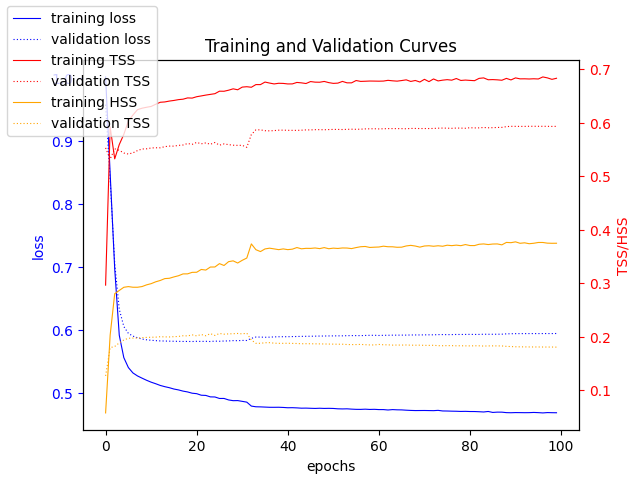

In [13]:
epochs = []
training_loss = []
validation_loss = []
training_tss = []
validation_tss = []
training_hss = []
validation_hss = []

previous_lr = optimizer.param_groups[0]['lr']

# for epoch in range(num_epochs):
for epoch in trange(num_epochs):
    
#     ### early stop for tss model
#     if epoch >= 41:
#         continue

    ### training loop
    model.train()
    running_loss = 0.0
    predicted_training_labels = np.array([])
    y_train = np.array([])
    
#     for data, target in tqdm(dataloader):
    for data, target in dataloader:
        
        data = data.to(device)
        target = target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        output.to(device)
        loss = criterion(output, target.float())
        loss.backward()
        optimizer.step()
        
        if scheduler_type == 'cos':
            scheduler.step()
        
        running_loss += loss.item()
        with torch.no_grad(): predicted_training_labels = np.append(predicted_training_labels, output.cpu())
        with torch.no_grad(): y_train = np.append(y_train, target.cpu())

    predicted_training_labels = np.where(predicted_training_labels > 0.1, 1, 0)

    train_loss = running_loss / len(dataloader)
    train_tss = true_skill_score(y_train.astype(int), predicted_training_labels.astype(int))
    train_hss = heidke_skill_score(y_train.astype(int), predicted_training_labels.astype(int))

    ### validation loop
    model.eval()
    with torch.no_grad():
        running_loss = 0.0
        predicted_val_labels = np.array([])
        y_val = np.array([])

#         for batch_data, labels in tqdm(val_dataloader):
        for batch_data, labels in val_dataloader:
        
            batch_data = batch_data.to(device)
            labels = labels.to(device)
            
            outputs = model(batch_data)
            outputs.to(device)
            loss = criterion(outputs, labels.float())
            running_loss += loss.item()
            predicted_val_labels = np.append(predicted_val_labels, outputs.cpu())
            y_val = np.append(y_val, labels.cpu())
            
    predicted_val_labels = np.where(predicted_val_labels > 0.1, 1, 0)

    val_loss = running_loss / len(val_dataloader)
    val_tss = true_skill_score(y_val.astype(int), predicted_val_labels.astype(int))
    val_hss = heidke_skill_score(y_val.astype(int), predicted_val_labels.astype(int))

#     print(f"Epoch [{epoch+1}/{num_epochs}]", end="\n\n")

#     print(f"Training Loss: {train_loss:.4f}, Training TSS: {train_TSS:.4f}")
#     print(f"Validation Loss: {val_loss:.4f}, Validation TSS: {val_TSS:.4f}", end="\n\n")

    epochs.append(epoch)
    training_loss.append(train_loss)
    validation_loss.append(val_loss)
    training_tss.append(train_tss)
    validation_tss.append(val_tss)
    training_hss.append(train_hss)
    validation_hss.append(val_hss)
    
    if scheduler_type == 'plat':
        if metric == 'tss':
            scheduler.step(val_tss) # when tuning for tss
        elif metric == 'hss':
            scheduler.step(val_hss) # when tuning for hss
            
        current_lr = scheduler.get_last_lr()[0]
        if current_lr < previous_lr:
            print(f"Learning rate reduced to: {current_lr}")
        previous_lr = current_lr
    

print(f"final train tss = {training_tss[-1]:.4f} : final val tss = {validation_tss[-1]:.4f}")
print(f"final train hss = {training_hss[-1]:.4f} : final val hss = {validation_hss[-1]:.4f}")
# plot_training_validation_curves(training_tss, validation_tss, training_loss, validation_loss, num_epochs)
# plot_training_validation_curves(training_hss, validation_hss, training_loss, validation_loss, num_epochs-4)
# plot_training_validation_curves(training_hss, validation_hss, training_loss, validation_loss, num_epochs)
plot_training_validation_curves(training_hss, validation_hss, training_tss, validation_tss, training_loss, validation_loss, num_epochs)


100%|██████████| 76/76 [00:00<00:00, 107.88it/s]



test_TSS: 0.6348

test_HSS: 0.2221

length of predicted_test_labels: 3465810
Value: 0, Count: 2961800 perc: 0.8545765636315897
Value: 1, Count: 504010 perc: 0.14542343636841026


Confusion matrix, without normalization
[[2936221  422722]
 [  25579   81288]]


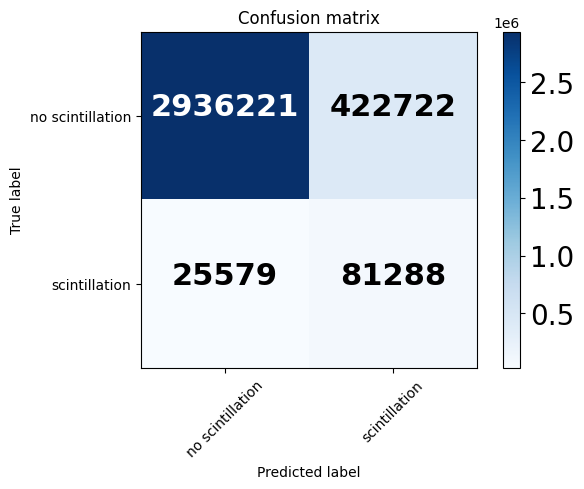

Normalized confusion matrix
[[0.87415029 0.12584971]
 [0.23935359 0.76064641]]


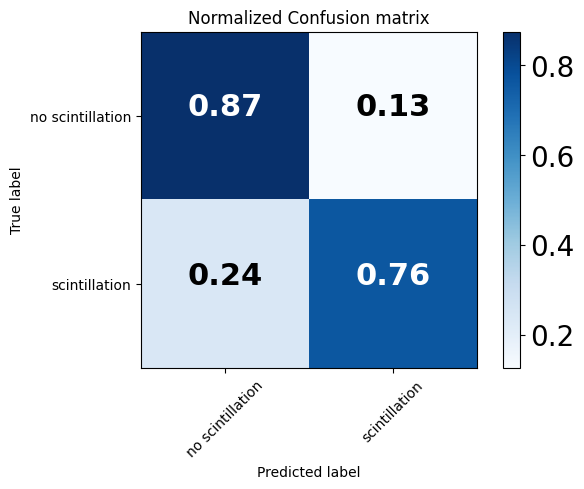

In [14]:
### test loop
predicted_test_labels = np.array([])

model.eval()
with torch.no_grad():
    for batch_data, labels in tqdm(test_dataloader):        
        batch_data = batch_data.to(device)
        labels.to(device)
        outputs = model(batch_data)
        predicted_test_labels = np.append(predicted_test_labels, outputs.cpu())

predicted_test_labels = np.where(predicted_test_labels > 0.1, 1, 0)

y_test_truncated = test_labels.squeeze().flatten().cpu().numpy()

cm = confusion_matrix_plots(y_test_truncated.astype(int), predicted_test_labels.astype(int))
TN,FP,TP,FN = cm.confusion_table()
# test_TSS = (TP/(TP+FN) - FP/(FP+TN))
test_tss = true_skill_score(y_test_truncated.astype(int), predicted_test_labels.astype(int))
test_hss = heidke_skill_score(y_test_truncated.astype(int), predicted_test_labels.astype(int))

print(end='\n')
# print(f"test_TSS: {test_TSS:.4f}", end='\n\n')
print(f"test_TSS: {test_tss:.4f}", end='\n\n')
print(f"test_HSS: {test_hss:.4f}", end='\n\n')

unique_values, counts = np.unique(predicted_test_labels, return_counts=True)
print("length of predicted_test_labels: {}".format(len(predicted_test_labels)))
for val, count in zip(unique_values, counts):
    perc = count/(len(predicted_test_labels))
    print(f"Value: {val}, Count: {count} perc: {perc}")

print(end='\n\n')

AUC_PRC = (average_precision_score(y_test_truncated,predicted_test_labels))
precision = ( TP/(TP+FP) )
recall = ( TP/(TP+FN) )
specificity = ( TN/(TN+FP) )
F1 = ( 2*((precision*recall)/(precision+recall)) )

cm_sklearn = confusion_matrix(y_test_truncated, predicted_test_labels)
confusion_matrix_class_names = ['no scintillation','scintillation']

fig1 = plt.figure()
cm.plot_confusion_matrix(cm_sklearn, classes=confusion_matrix_class_names, normalize=False, title='Confusion matrix')
plt.show()

fig2 = plt.figure()
cm.plot_confusion_matrix(cm_sklearn, classes=confusion_matrix_class_names, normalize=True, title='Normalized Confusion matrix')
plt.show()

In [15]:
processed_data_2016 = pd.read_csv("processed_data_2016.csv")
processed_data_2016 = processed_data_2016.drop(processed_data_2016.columns[0], axis=1)
predicted_label = 'sigmaPhi projected to vertical at prediction time [radians]'
y_2016 = processed_data_2016[predicted_label].values
print(y_2016.shape)

X_2016_fSelect = processed_data_2016.drop(predicted_label, axis=1)
X_2016_fSelect = X_2016_fSelect.values
print(X_2016_fSelect.shape)

X_scaled_2016 = scaler_X.transform(X_2016_fSelect)

X_scaled_2016 = reshape_data_to_seq_length(X_scaled_2016, seq_length)
test_labels_2016 = reshape_labels_to_seq_length(y_2016, seq_length)

test_data_2016 = torch.tensor(X_scaled_2016, dtype=torch.float32).transpose(1, 2)  # Shape: [batch_size, 15, 1]
test_data_2016.to(device)
test_labels_2016.to(device)
test_dataset_2016 = TensorDataset(test_data_2016, test_labels_2016)
test_dataloader_2016 = DataLoader(test_dataset_2016, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker)

(126426,)
(126426, 15)


100%|██████████| 3/3 [00:00<00:00, 160.79it/s]


test_TSS_2016: 0.5646

test_HSS_2016: 0.2053

length of predicted_test_labels_2016: 126405
Value: 0, Count: 106951 perc: 0.8460978600530042
Value: 1, Count: 19454 perc: 0.15390213994699578


Confusion matrix, without normalization
[[105651  16432]
 [  1300   3022]]


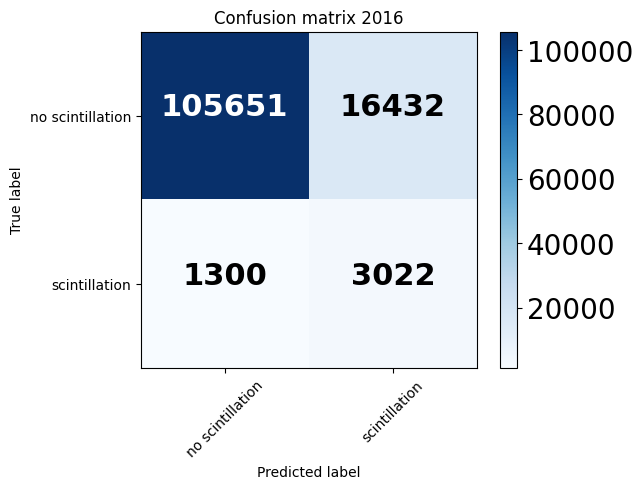

Normalized confusion matrix
[[0.86540305 0.13459695]
 [0.30078667 0.69921333]]


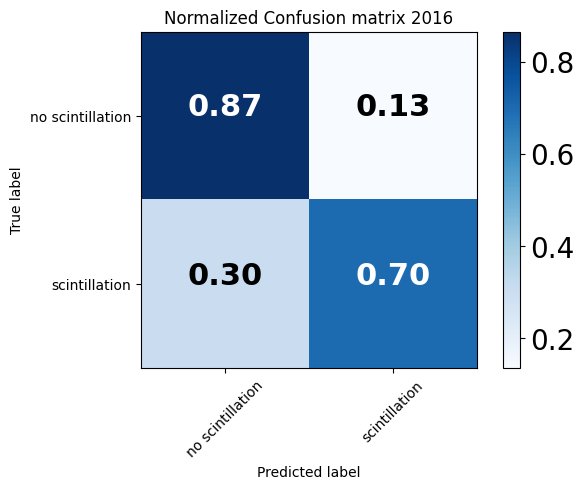

In [16]:
### test loop 2016
predicted_test_labels_2016 = np.array([])

model.eval()
with torch.no_grad():
    for batch_data, labels in tqdm(test_dataloader_2016):
        batch_data = batch_data.to(device)
        labels = labels.to(device)
        outputs = model(batch_data)
        predicted_test_labels_2016 = np.append(predicted_test_labels_2016, outputs.cpu())

predicted_test_probs_2016 = predicted_test_labels_2016.copy()
predicted_test_labels_2016 = np.where(predicted_test_labels_2016 > 0.1, 1, 0)

y_2016_truncated = test_labels_2016.squeeze().flatten().cpu().numpy()

cm = confusion_matrix_plots(y_2016_truncated.astype(int), predicted_test_labels_2016.astype(int))
TN,FP,TP,FN = cm.confusion_table()
test_tss_2016 = (TP/(TP+FN) - FP/(FP+TN))
test_hss_2016 = heidke_skill_score(y_2016_truncated.astype(int), predicted_test_labels_2016.astype(int))

print(end='\n')
print(f"test_TSS_2016: {test_tss_2016:.4f}", end='\n\n')
print(f"test_HSS_2016: {test_hss_2016:.4f}", end='\n\n')

unique_values, counts = np.unique(predicted_test_labels_2016, return_counts=True)
print("length of predicted_test_labels_2016: {}".format(len(predicted_test_labels_2016)))
for val, count in zip(unique_values, counts):
    perc = count/(len(predicted_test_labels_2016))
    print(f"Value: {val}, Count: {count} perc: {perc}")

print(end='\n\n')

AUC_PRC = (average_precision_score(y_2016_truncated,predicted_test_labels_2016))
precision = ( TP/(TP+FP) )
recall = ( TP/(TP+FN) )
specificity = ( TN/(TN+FP) )
F1 = ( 2*((precision*recall)/(precision+recall)) )

cm_sklearn = confusion_matrix(y_2016_truncated, predicted_test_labels_2016)
confusion_matrix_class_names = ['no scintillation','scintillation']

fig1 = plt.figure()
cm.plot_confusion_matrix(cm_sklearn, classes=confusion_matrix_class_names, normalize=False, title='Confusion matrix 2016')
plt.show()

fig2 = plt.figure()
cm.plot_confusion_matrix(cm_sklearn, classes=confusion_matrix_class_names, normalize=True, title='Normalized Confusion matrix 2016')
plt.show()

In [17]:
### test loop 2016
predicted_test_labels_2016 = np.array([])

model.eval()
with torch.no_grad():
    for batch_data, labels in tqdm(test_dataloader_2016):
        batch_data = batch_data.to(device)
        labels = labels.to(device)
        outputs = model(batch_data)
        predicted_test_labels_2016 = np.append(predicted_test_labels_2016, outputs.cpu())

predicted_test_probs_2016 = predicted_test_labels_2016.copy()
y_2016_truncated = test_labels_2016.squeeze().flatten().cpu().numpy()

# predicted_probabilities_2016 = model.predict_proba(X_test)[:, 1]  # Select probabilities for the positive class

from sklearn.metrics import roc_auc_score
# auc = roc_auc_score(y_2016_truncated, predicted_probabilities_2016)
auc = roc_auc_score(y_2016_truncated, predicted_test_probs_2016)

print(f"AUC-ROC: {auc:.2}")
from sklearn.metrics import precision_recall_curve, auc
precision, recall, _ = precision_recall_curve(y_2016_truncated, predicted_test_probs_2016)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.2}")


100%|██████████| 3/3 [00:00<00:00, 186.72it/s]

AUC-ROC: 0.89
Precision-Recall AUC: 0.26


In [18]:
# ### persistence calculation
# current_scint_2015 = np.array(processed_data_2015['sigmaPhi projected to vertical [radians]'])
# predicted_scint_2015 = np.array(processed_data_2015['sigmaPhi projected to vertical at prediction time [radians]'])
# current_labels_2015 = np.where(current_scint_2015 > 0.1, 1, 0)
# predicted_labels_2015 = np.where(predicted_scint_2015 > 0.1, 1, 0)

# persistence_tss_2015 = true_skill_score(current_labels_2015, predicted_labels_2015)
# persistence_hss_2015 = heidke_skill_score(current_labels_2015, predicted_labels_2015)
# print(f"persistence_tss_2015: {persistence_tss_2015}")
# print(f"persistence_hss_2015: {persistence_hss_2015}")
# print()

# current_scint_2016 = np.array(processed_data_2016['sigmaPhi projected to vertical [radians]'])
# predicted_scint_2016 = np.array(processed_data_2016['sigmaPhi projected to vertical at prediction time [radians]'])
# current_labels_2016 = np.where(current_scint_2016 > 0.1, 1, 0)
# predicted_labels_2016 = np.where(predicted_scint_2016 > 0.1, 1, 0)

# persistence_tss_2016 = true_skill_score(current_labels_2016, predicted_labels_2016)
# persistence_hss_2016 = heidke_skill_score(current_labels_2016, predicted_labels_2016)
# print(f"persistence_tss_2016: {persistence_tss_2016}")
# print(f"persistence_hss_2016: {persistence_hss_2016}")
# print()


# current_labels = np.concatenate((current_labels_2015, current_labels_2016))
# predicted_labels = np.concatenate((predicted_labels_2015, predicted_labels_2016))

# persistence_tss = true_skill_score(current_labels, predicted_labels)
# persistence_hss = heidke_skill_score(current_labels, predicted_labels)
# print(f"persistence_tss: {persistence_tss}")
# print(f"persistence_hss: {persistence_hss}")

